# Wikipedia Network Analysis: Node Centralities and Hubs

In this notebook we analyze the centrality measures of nodes in the Wikipedia network to identify important articles and understand what characterizes them.

We will analyze the following centrality measures:
- **Out Degree Centrality**: Measures the number of outgoing connections
- **In Degree Centrality**: Measures the number of incoming connections
- **Katz Centrality**: Measure the importance of a node by considering connections to important nodes
- **Closeness Centrality**: Measures how close a node is to all other nodes on avarage
- **Betweenness Centrality**: Measures how many shortest paths pass through a node


## Import Libraries and Load Data

In [18]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import unquote
CREATE_DATASET = False
np.random.seed(42)

In [19]:
#load data
df_articles = pd.read_csv('./data/datasets/articles.tsv', sep='\t', skiprows=12, names=['article'])
df_articles["article"] = df_articles["article"].apply(lambda x: unquote(x))

df_links = pd.read_csv('./data/datasets/links.tsv', sep='\t', skiprows=12, names=['source', 'target'])
df_links["source"] = df_links["source"].apply(lambda x: unquote(x))
df_links["target"] = df_links["target"].apply(lambda x: unquote(x))

#create graph
G = nx.DiGraph()
G.add_nodes_from(df_articles["article"])
G.add_edges_from(zip(df_links["source"], df_links["target"]))

#extract largest strongly connected component 
strongly_connected_components = sorted(list(nx.strongly_connected_components(G)), reverse=True, key=len)
core_nodes = strongly_connected_components[0]
C = G.subgraph(core_nodes)

## Centrality

We'll calculate 5 different centrality measures on the strongly connected component to identify important nodes in the network. We use all these measures to provide a complete overview of the network. In the the context of the wikipedia network and the wikispeedia game, each centrility measure provides different kind of insight:

- High **out-degree centrality** means the article has many hyperlinks to other articles. It indicates hub articles that are locally useful for navigation.

- High **in-degree centrality** means many incoming links to the article, indicating it is a important article and easy to reach.

- High **Katz centrality** means the article is important and connected to other important articles. 

- High **closeness centrality** means the article is, on average, close to all other articles. It indicates structurally central articles that are easy to reach as target or to start with as source.

- High **betweenness centrality** means the article is a bridge between other articles, indicating it is strategically important for connecting different parts of the network.






In [20]:
# Calculate centrality measures
if CREATE_DATASET:
    out_degree_centrality = nx.out_degree_centrality(C)
    in_degree_centrality = nx.in_degree_centrality(C)
    katz_centrality = nx.katz_centrality(C, alpha=0.01, beta=1.0)
    closeness_centrality = nx.closeness_centrality(C)
    betweenness_centrality = nx.betweenness_centrality(C)

    #create df with all centrality measures
    centrality_df = pd.DataFrame({
        'node': list(C.nodes()),
        'out_degree_centrality': [round(out_degree_centrality[node],4) for node in C.nodes()],
        'in_degree_centrality': [round(in_degree_centrality[node],4) for node in C.nodes()],
        'katz_centrality': [round(katz_centrality[node],4) for node in C.nodes()],
        'closeness_centrality': [round(closeness_centrality[node],4) for node in C.nodes()],
        'betweenness_centrality': [round(betweenness_centrality[node],4) for node in C.nodes()]   
    })
    #save df to csv
    centrality_df.to_csv('./data/mydata/centrality_measures.csv', index=False)
    
else:#read dataset if it already exists
    centrality_df = pd.read_csv('./data/mydata/centrality_measures.csv')

## Top Nodes by Centrality Measure


In [21]:
# Display top 10 nodes for each centrality measure
measures =['out_degree_centrality', 'in_degree_centrality','katz_centrality','closeness_centrality', 'betweenness_centrality' ]
K = 10  # Number of top nodes to display
top_dict = {}
last_dict = {}

for measure in measures:
    top_nodes = centrality_df.sort_values(measure, ascending=False).head(K)['node'].reset_index(drop=True)
    top_dict[measure] = top_nodes
    last_nodes = centrality_df.sort_values(measure, ascending=False).tail(K)['node'].reset_index(drop=True)
    last_dict[measure] = last_nodes

top_table = pd.DataFrame(top_dict)
last_table = pd.DataFrame(last_dict)

print("TOP nodes by Centrality: ")
display(top_table)
print("LAST nodes by Centrality: ")
display(last_table)


TOP nodes by Centrality: 


,out_degree_centrality,in_degree_centrality,katz_centrality,closeness_centrality,betweenness_centrality
0,United_States,United_States,United_States,United_States,United_States
1,List_of_countries,United_Kingdom,France,Europe,United_Kingdom
2,List_of_circulating_currencies,France,United_Kingdom,United_Kingdom,England
3,List_of_sovereign_states,Europe,Europe,France,Europe
4,Africa,Germany,Germany,Germany,Africa
5,List_of_countries_by_system_of_government,England,World_War_II,World_War_II,Germany
6,Lebanon,World_War_II,English_language,India,19th_century
7,Interpol,India,India,English_language,World_War_II
8,Armenia,English_language,Spain,Latin,London
9,Georgia_(country),Japan,Russia,England,Earth


LAST nodes by Centrality: 


,out_degree_centrality,in_degree_centrality,katz_centrality,closeness_centrality,betweenness_centrality
0,WorkChoices,Amazon_parrot,Harley-Davidson,16_Cygni_Bb,Montreal_Metro
1,Human_dignity,Amaranth_oil,Hardball_squash,Northern_Pacific_Railway,Mount_Unzen
2,Soil_profile,Tansy,Haraldskær_Woman,Ffestiniog_Railway,Mount_Rainier
3,Inductance,The_Beatles_discography,Harald_Maddadsson,Great_Comet_of_1882,"Mount_Osmond,_South_Australia"
4,Soil_structure,The_Absent-Minded_Beggar,Helen_Gandy,Costume_design,Mount_Nyiragongo
5,Lighting_designer,Temple_of_Artemis,Hawaiian_Goose,Issyk_Kul,Mount_Baker
6,Hello_Garci_scandal,The_Illuminatus!_Trilogy,Zebra_shark,Rio_Tinto_Group,Mother_Teresa
7,Classic_female_blues,The_Curious_Incident_of_the_Dog_in_the_Night-time,2-6-0,Tufted_Duck,Moss
8,Scheme_programming_language,The_Picture_of_Dorian_Gray,"Yarralumla,_Australian_Capital_Territory",Black_panther,Zuid-Gelders
9,Malaspina_Glacier,The_Lorax,Yagan,Timken_1111,Zion_National_Park


### Results

A preliminary analysis show that many of the **top nodes** across different centrality measures are the same, suggesting a certain degree of correlation between them.  
Most of these nodes appear to be articles about **countries**.  

One notable exception is Out-Degree Centrality, which includes many "list-of" type articles in its top 10.  
These articles are specifically designed to group lists of links to other articles. While they might initially seem useful in the context of Wikispeedia due to their high number of outgoing links, but their absence from the top rankings in other measures, especially betweenness and closeness, suggests that they may not actually be useful when searching for short paths between articles.  
A possible explanation is that, despite having many hyperlinks, these links often point to articles in the same domanin. This limits their ability to connect different areas of the network, and therefore they don't offer the broad navigability that we might expect.

As for the **bottom-ranked nodes**, it’s harder to identify clear patterns. There are actually hundreds of nodes sharing the same minimal centrality values, and the 10 shown are not a representative sample of the vast majority of low-centrality nodes. Still, most appear to be small, niche articles with few links. Interestingly, those few links often point to top-ranked or nearby articles.
This means that challenges starting from these nodes may not be particularly difficult, but reaching them from other parts of the network might be.  

Further analysis will be conducted when we examine the paths used in the Wikispeedia challenges.


In [22]:
from collections import Counter
top_n = 20
measures =['out_degree_centrality', 'in_degree_centrality','katz_centrality','closeness_centrality', 'betweenness_centrality' ]
# Collect all top-N nodes across all centrality measures
all_top_nodes = []
for measure in measures:
    top_nodes = centrality_df.sort_values(measure, ascending=False).head(top_n)['node']
    all_top_nodes.extend(top_nodes)

#Count how many times each node appears
node_frequencies = Counter(all_top_nodes)

print(f"Nodes appearing in the top {top_n} for multiple centrality measures:")
for node in sorted(node_frequencies, key=lambda n: node_frequencies[n], reverse=True)[:top_n]:
    print(f"{node} (appears in {node_frequencies[node]} measures)")

    

Nodes appearing in the top 20 for multiple centrality measures:
United_States (appears in 5 measures)
England (appears in 5 measures)
Germany (appears in 5 measures)
United_Kingdom (appears in 5 measures)
France (appears in 4 measures)
Europe (appears in 4 measures)
World_War_II (appears in 4 measures)
India (appears in 4 measures)
English_language (appears in 4 measures)
Japan (appears in 4 measures)
Canada (appears in 4 measures)
Australia (appears in 4 measures)
Russia (appears in 4 measures)
China (appears in 4 measures)
Africa (appears in 3 measures)
London (appears in 3 measures)
Italy (appears in 3 measures)
Spain (appears in 3 measures)
Latin (appears in 3 measures)
19th_century (appears in 2 measures)


We can confirm that the most central articles across multiple centrality measures are predominantly about **countries**.  

This is likely due to the fact that country related articles are among the most well structured in the English Wikipedia dataset. One possible explanation is that countries are relatively easier to describe and expand. A typical article about a country includes multiple sections covering diverse topics (e.g., history, geography, culture, economy), which leads to a high number of outgoing links spanning various semantic areas.  
Additionally, countries are frequently referenced in other articles, since it is common to mention the country when describing any entity (e.g., people, events, locations).

It is also worth noting that the top two nodes are **"United States"** and **"United Kingdom"**, probably reflecting a bias in the dataset since we are working with the English Wikipedia.

Also notable is the presence of nodes like **"World_War_II"** and **"19th_Century"** among the most central articles. These serve as aggregators of events and topics. Their presence is mostly arbitrary, structurally, they are not fundamentally different from articles like **"World_War_I"** or **"20th_Century"**, but their historical significance and the cummunity's interest have likely led to more developed articles.


## Centrality Distributions

Let's examine the distribution of centrality values across all nodes.

In [23]:
measures = ['out_degree_centrality', 'in_degree_centrality','katz_centrality','closeness_centrality', 'betweenness_centrality' ]
centrality_df = pd.read_csv('./data/mydata/centrality_measures.csv')
for measure in measures:
    mean=centrality_df[measure].mean()
    min= centrality_df[measure].min()
    max= centrality_df[measure].max()
    print(f"- {measure}:")
    print(f"    min={min:.4f} max={max:.4f} mean={mean:.4f}")

- out_degree_centrality:
    min=0.0002 max=0.0726 mean=0.0068
- in_degree_centrality:
    min=0.0002 max=0.3444 mean=0.0068
- katz_centrality:
    min=0.0072 max=0.2003 mean=0.0118
- closeness_centrality:
    min=0.1460 max=0.5952 mean=0.3253
- betweenness_centrality:
    min=0.0000 max=0.1036 mean=0.0005


In [ ]:
#Define functions for computing and plotting CCDF, CDF, and histogram
def compute_cdf(data):
    cdf = np.arange(1, len(data) + 1) / len(data)
    return cdf

def compute_ccdf(cdf):
    ccdf = 1 - cdf
    return ccdf

def freedman_diaconis_bins(data):
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    bin_width = 2 * iqr / np.cbrt(len(data))
    bins = int((data.max() - data.min()) / bin_width) or 1 
    return bins

def plot_distributions(data, measure_name,):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Calculate optimal bins using Freedman-Diaconis rule
    optimal_bins = freedman_diaconis_bins(data)
    

    data = np.sort(data)
    #Histogram with probability density
    axes[0].hist(data, bins=optimal_bins, alpha=0.7, edgecolor='black', color='skyblue')
    axes[0].set_title(f'{measure_name}\nHistogram')
    axes[0].set_xlabel('Centrality Value')
    axes[0].set_ylabel('Frequency')
    axes[0].set_xscale('log')
       
    #CDF
    cdf_values = compute_cdf(data)
    axes[1].plot(data, cdf_values, marker='o', linestyle='-', markersize=2, linewidth=1.5, color='green')
    axes[1].set_title(f'{measure_name}\nCDF (P(X ≤ x))')
    axes[1].set_xlabel('Centrality Value')
    axes[1].set_ylabel('CDF')   
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1)
    
    #CCDF (log-log scale)
    ccdf_values = compute_ccdf(cdf_values)
    axes[2].plot(data, ccdf_values, marker='o', linestyle='none', markersize=3, color='red')
    axes[2].set_title(f'{measure_name}\nCCDF (P(X > x))')
    axes[2].set_xlabel('Centrality Value')
    axes[2].set_ylabel('CCDF')
    axes[2].set_xscale('log')
    axes[2].set_yscale('log')
    axes[2].grid(True, which="both", ls="--", lw=0.5, alpha=0.3)
    
    plt.savefig(f'./img/{measure_name.replace(" ", "_").lower()}_distribution.png', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()
    


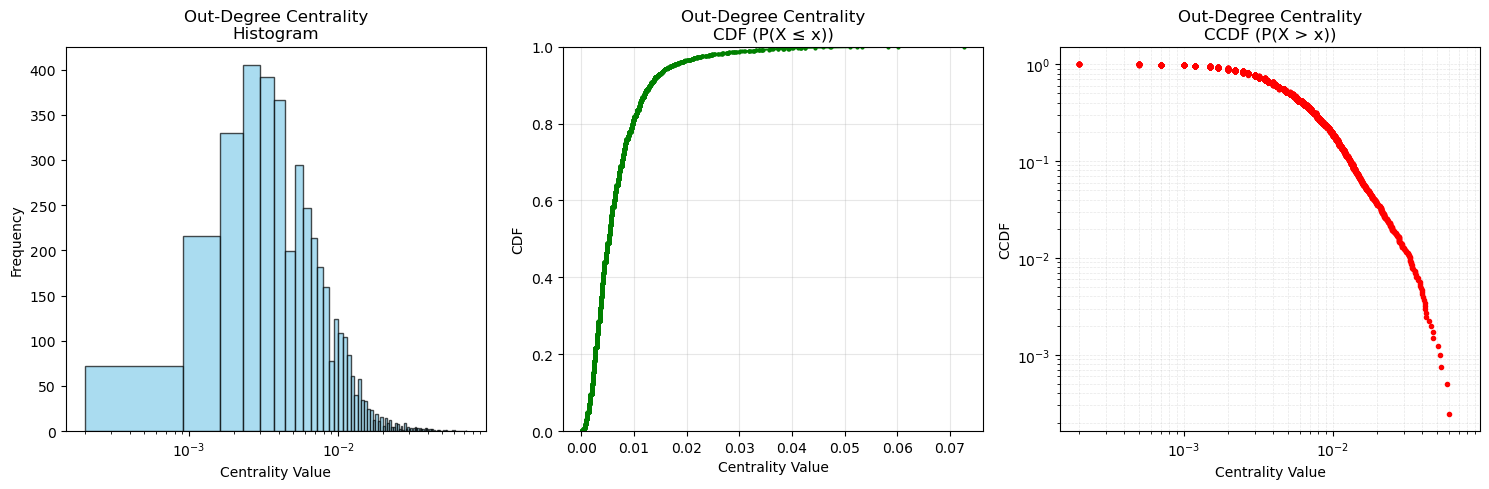

In [8]:
# Out-Degree Centrality
plot_distributions(centrality_df["out_degree_centrality"], "Out-Degree Centrality")

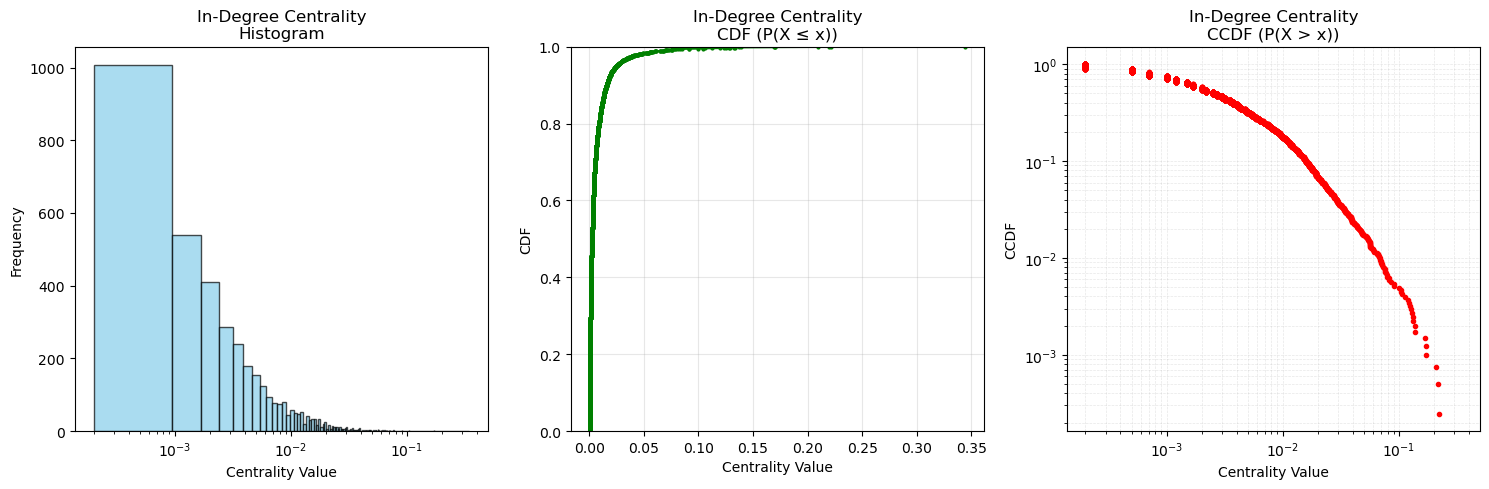

In [9]:
# In-Degree Centrality 
plot_distributions(centrality_df["in_degree_centrality"], "In-Degree Centrality")

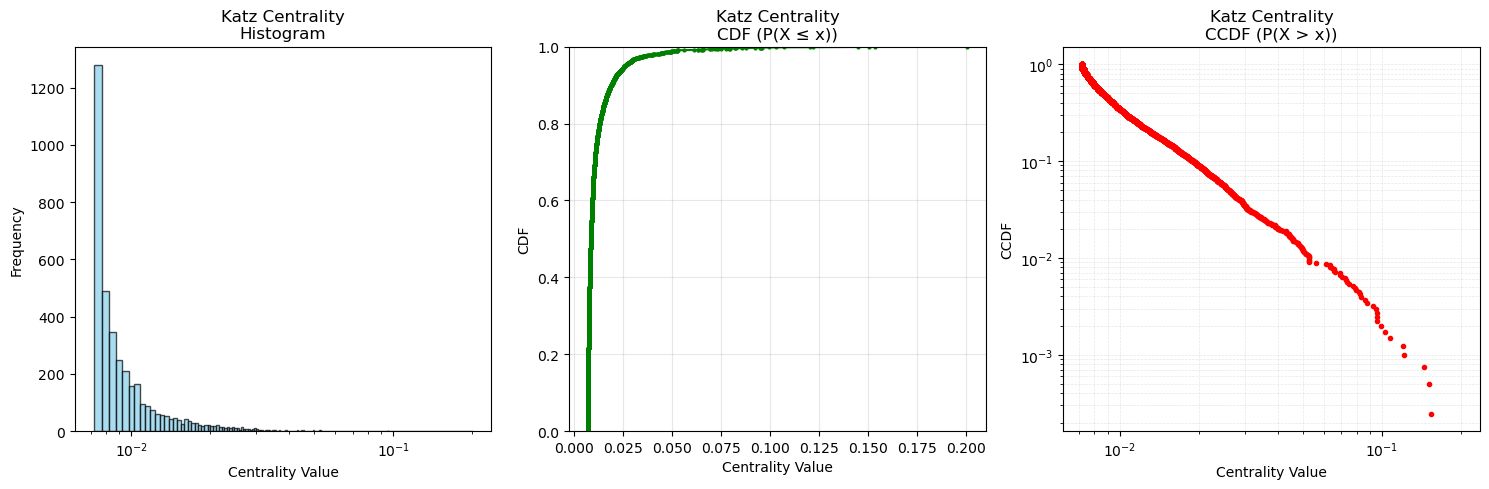

In [10]:
# Katz Centrality
plot_distributions(centrality_df["katz_centrality"], "Katz Centrality")

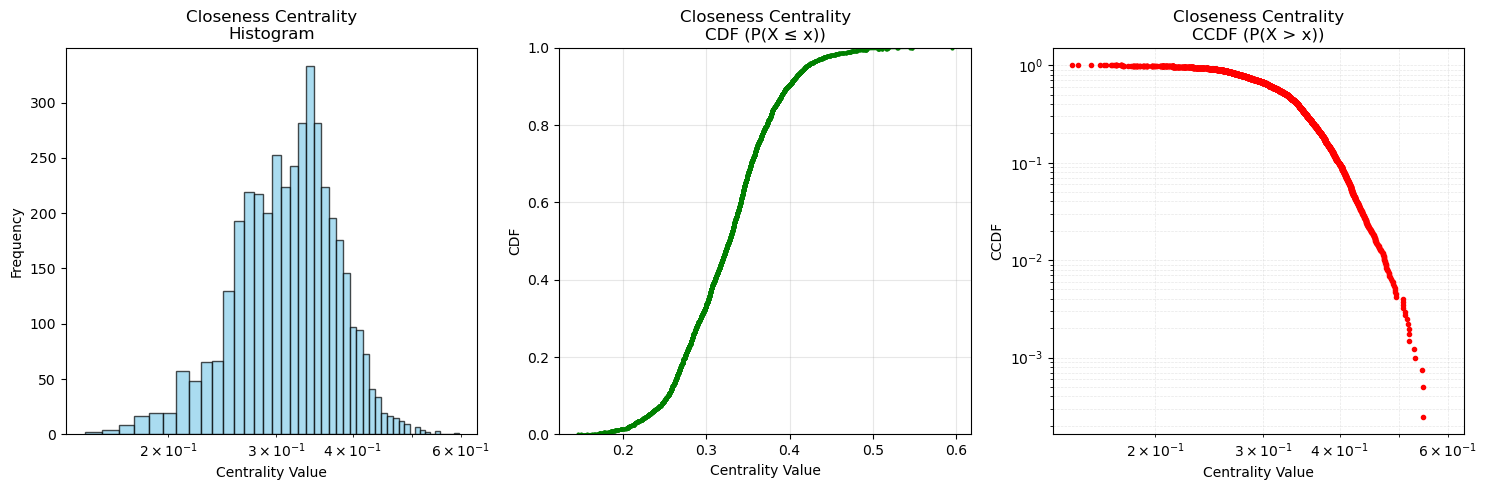

In [11]:
# Closeness Centrality
plot_distributions(centrality_df["closeness_centrality"], "Closeness Centrality")

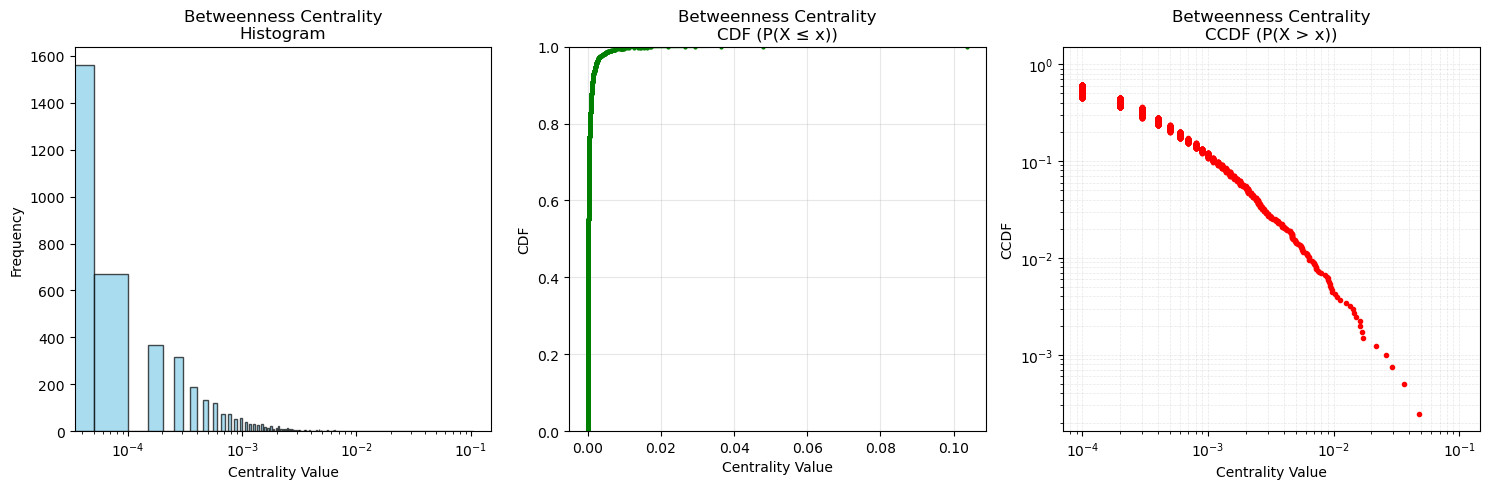

In [12]:
# Betweenness Centrality
plot_distributions(centrality_df["betweenness_centrality"], "Betweenness Centrality")

###  Results

The distribution analysis reveals that all centrality measures follow **heavy-tailed distributions**, the histograms show highly skewed patterns, with most nodes having very low centrality values and only a few nodes reaching high centrality.

The log-log CCDF plots indicate a distribution close to power-law behavior, particularly evident in Katz centrality.

Betweenness centrality shows the most extreme concentration, with the vast majority of nodes having near-zero values and only a tiny fraction serving as critical bridges in the network. 

Closeness centrality exhibits a more bell shape distribution concentrated around the mean, suggesting that most nodes network maintain similar average distances to other nodes.

## Correlation Analysis

Let's examine the correlations between different centrality measures to understand their relationships.

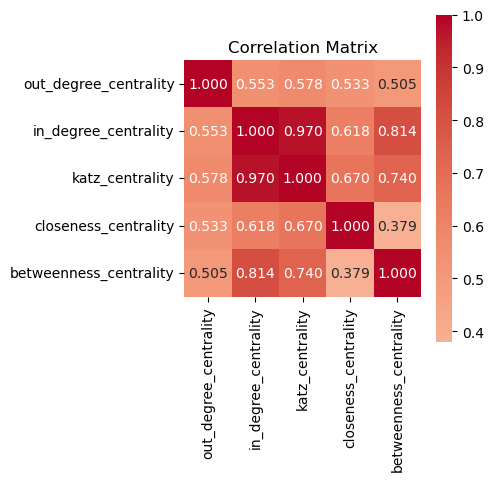

In [13]:

measures =['out_degree_centrality', 'in_degree_centrality','katz_centrality','closeness_centrality', 'betweenness_centrality' ]
pearson_corr = centrality_df[measures].corr()

fig = plt.figure(figsize=(5, 5))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Results
As expected, **all centrality measures are positively correlated with each other**.  
In particular, there is a strong correlation between In-Degree and Katz Centrality, since Katz Centrality builds on In-Degree by also considering neighbors at multiple levels of distance.  
Overall, these two measures show strong correlations with the others as well, suggesting that they are good predictors of node importance in the network.

It is also interesting to note the relatively weak correlation between Closeness and Betweenness Centrality, although these two metrics are conceptually related, being close to all other nodes does not necessarily imply being a bridge in the network, and vice versa.


## Summary and Conclusions


This analysis of node centralities within the Wikipedia network offers several insights into the structure and importance of articles.

1. **Network Structure**:  The Wikipedia network exhibits a heavy-tailed distribution across centrality measures, meaning that a small number of nodes act as highly connected hubs while the vast majority of nodes have relatively low connectivity. This structure suggests that leveraging these hub nodes could provide a strategic advantage when navigating or playing the Wiki Game, as they serve as key points that link many other articles.

2. **Centrality Measures**:  Although the various centrality metrics are positively correlated, each measure highlights a different aspects. Among them, In-Degree and Katz Centrality appear to be the most reliable predictors of a node's overall significance in the network.

3. **Top Nodes**:  The analysis of the highest-ranking nodes across centrality measures consistently shows that articles related to **countries** dominate in all centrality measures. Probably, because country articles tend to be well-structured, with extensive sections covering diverse topics, and are frequently referenced in other pages.